# 实验二：可视化分析

数据集：`./datasets/shop_payNum_new.csv`

本 Notebook 使用 `pandas` 封装的绘图接口完成折线图、柱状图和饼图的绘制。

In [5]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 配置 Matplotlib 中文字体，兼容 macOS 与常见 Windows 环境，避免标题、坐标轴和图例出现乱码。
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Heiti SC', 'STHeiti', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 读取数据时直接解析 time_stamp 为 Datetime 类型，并将其设置为行索引。
data_path = './datasets/shop_payNum_new.csv'
df = pd.read_csv(data_path, parse_dates=['time_stamp'], index_col='time_stamp')

# 查看前 5 行数据，确认字段读取无误。
df.head()

,shop_id,pay_num,cate_2_name
time_stamp,,,
2016-01-01,14,33,fast food
2016-01-02,14,35,fast food
2016-01-03,14,20,fast food
2016-01-04,14,53,fast food
2016-01-05,14,54,fast food


In [6]:
# 补充查看数据的基本信息，确认索引类型、缺失情况和字段类型。
print('数据形状：', df.shape)
print('时间范围：', df.index.min().date(), '到', df.index.max().date())
print('商家类别数：', df['cate_2_name'].nunique())
print('示例 shop_id 是否存在：', 14 in df['shop_id'].unique())
df.info()

数据形状： (10026, 3)
时间范围： 2016-01-01 到 2016-10-31
商家类别数： 5
示例 shop_id 是否存在： True
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10026 entries, 2016-01-01 to 2016-10-31
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   shop_id      10026 non-null  int64 
 1   pay_num      10026 non-null  int64 
 2   cate_2_name  10026 non-null  object
dtypes: int64(2), object(1)
memory usage: 313.3+ KB


## 任务 1：绘制每类商家 10 月份的日平均客流量折线图

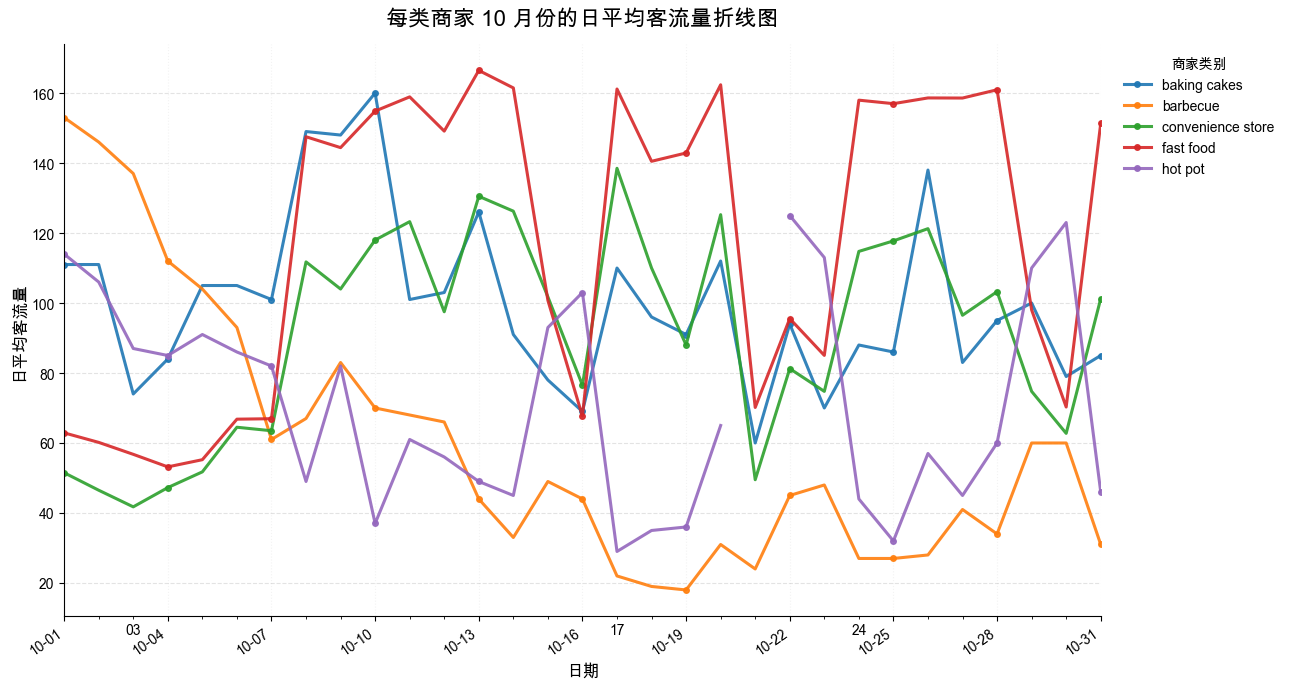

In [7]:
# 1. 筛选出 10 月份的数据。
october_data = df[df.index.month == 10].copy()

# 2. 以“日期 + 商家类别”为分组键，对 pay_num 求平均值。
#    normalize() 的作用是把时间统一到当天 00:00:00，便于按日统计。
october_daily_avg = (
    october_data
    .groupby([october_data.index.normalize(), 'cate_2_name'])['pay_num']
    .mean()
    .unstack()
    .sort_index()
)

# 3. 使用 pandas 封装的 plot(kind='line') 绘制折线图，并做样式优化。
import matplotlib.dates as mdates

ax = october_daily_avg.plot(
    kind='line',
    figsize=(13, 7),
    linewidth=2.2,
    marker='o',
    markersize=4,
    markevery=3,
    alpha=0.9
)

# 4. 设置标题、坐标轴、图例和网格，让图面更清晰。
ax.set_title('每类商家 10 月份的日平均客流量折线图', fontsize=16, fontweight='bold', pad=14)
ax.set_xlabel('日期', fontsize=12)
ax.set_ylabel('日平均客流量', fontsize=12)
ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.grid(axis='x', linestyle=':', alpha=0.15)

# 日期刻度按 3 天显示一次，减少横轴拥挤。
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.xticks(rotation=35, ha='right')

# 图例放在图外，避免遮挡曲线。
ax.legend(title='商家类别', frameon=False, loc='upper left', bbox_to_anchor=(1.01, 1.0))

# 去掉顶部与右侧边框，让视觉更简洁。
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 任务 2：绘制商家 `shop_id == 14` 的每月总客流量柱状图

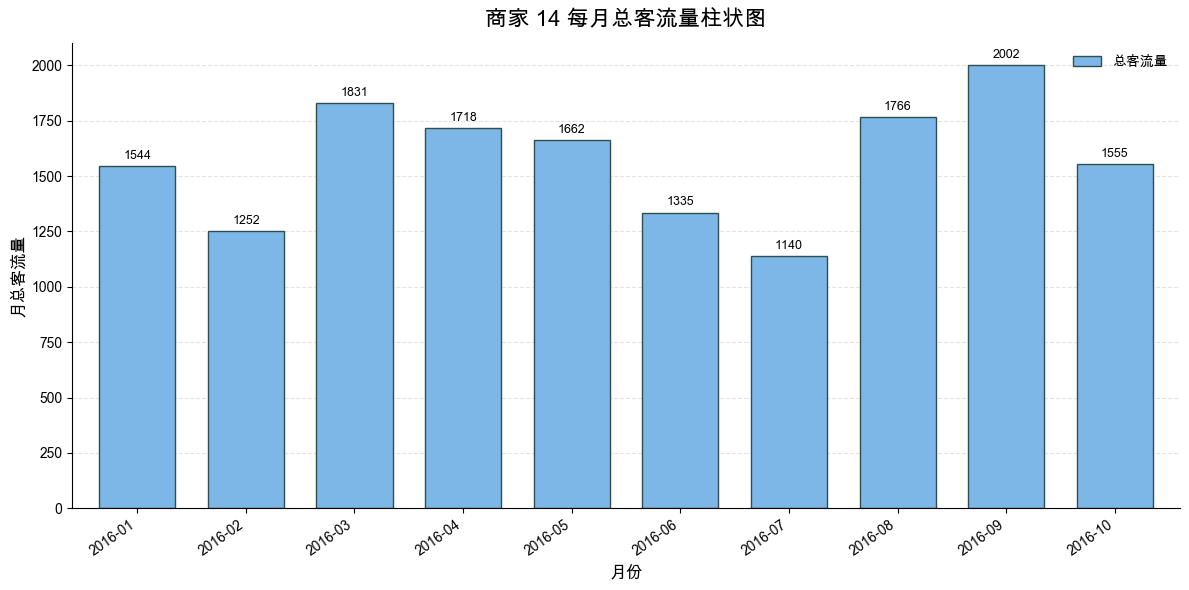

In [8]:
# 1. 选择一个具体商家，这里按题目示例选取 shop_id == 14。
shop_id_target = 14
shop_data = df[df['shop_id'] == shop_id_target].copy()

# 2. 因为 time_stamp 已经是 DatetimeIndex，直接按月重采样并求和即可。
#    resample('ME') 表示按月末频率统计，sum() 表示计算每月总客流量。
monthly_total = shop_data['pay_num'].resample('ME').sum()

# 3. 将时间索引转换为“年-月”字符串，便于柱状图横轴展示。
monthly_total.index = monthly_total.index.strftime('%Y-%m')

# 4. 使用 pandas 封装的 plot(kind='bar') 绘制柱状图，并优化视觉细节。
ax = monthly_total.plot(
    kind='bar',
    figsize=(12, 6),
    color='#7DB7E8',
    edgecolor='#2F4F4F',
    linewidth=1.0,
    width=0.7
)

# 5. 设置图表标题、坐标轴标签、网格线和数值标注。
ax.set_title(f'商家 {shop_id_target} 每月总客流量柱状图', fontsize=16, fontweight='bold', pad=12)
ax.set_xlabel('月份', fontsize=12)
ax.set_ylabel('月总客流量', fontsize=12)
ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.legend(['总客流量'], frameon=False)

# 柱顶标注每月客流量，便于读数。
for bar in ax.patches:
    h = bar.get_height()
    ax.annotate(
        f'{h:.0f}',
        (bar.get_x() + bar.get_width() / 2, h),
        ha='center',
        va='bottom',
        fontsize=9,
        xytext=(0, 3),
        textcoords='offset points'
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

## 任务 3：绘制 10 月各类别商店总客流量占比饼图

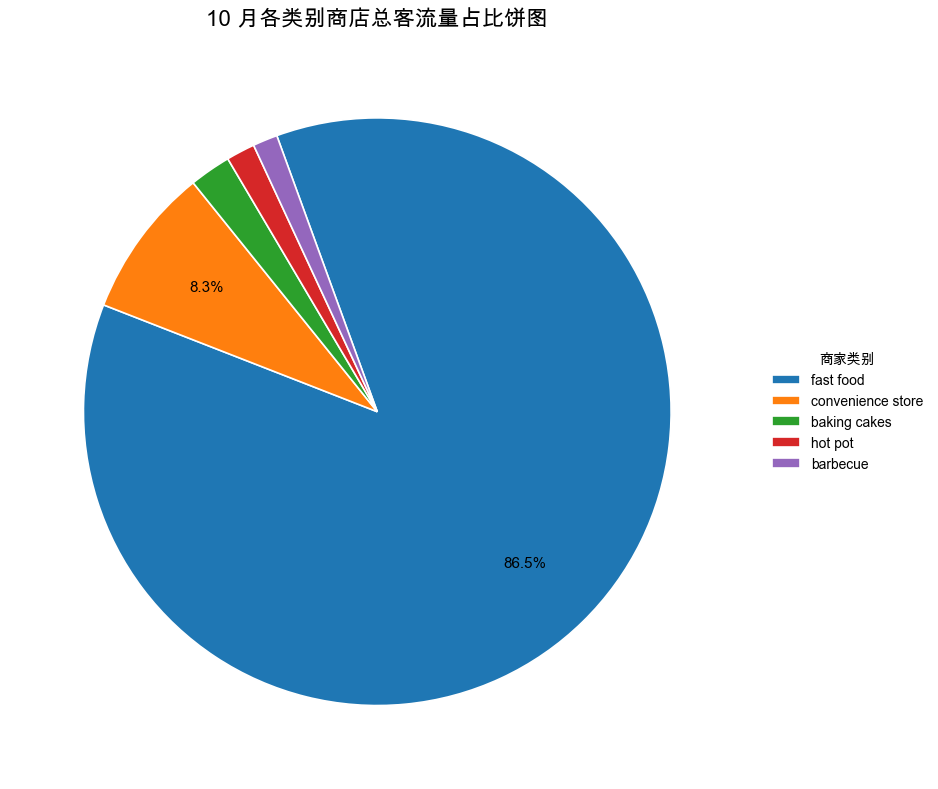

In [9]:
# 1. 再次筛选 10 月数据，并按 cate_2_name 分组统计 pay_num 总和。
october_category_total = (
    df[df.index.month == 10]
    .groupby('cate_2_name')['pay_num']
    .sum()
    .sort_values(ascending=False)
)

# 2. 使用 matplotlib 的 pie 绘制饼图（图类型不变），并避免标签拥挤。
#    小于阈值的扇区不显示百分比，类别名称统一放在图例中。
def fmt_pct(pct):
    return f'{pct:.1f}%' if pct >= 3 else ''

fig, ax = plt.subplots(figsize=(9.5, 8))
wedges, texts, autotexts = ax.pie(
    october_category_total.values,
    labels=None,
    autopct=fmt_pct,
    startangle=110,
    counterclock=False,
    pctdistance=0.72,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
    textprops={'fontsize': 11}
 )

# 3. 设置标题和图例，使占比信息更清晰。
ax.set_title('10 月各类别商店总客流量占比饼图', fontsize=16, fontweight='bold', pad=14)
ax.legend(
    wedges,
    october_category_total.index,
    title='商家类别',
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## 结果说明

1. 折线图用于展示不同商家类别在 10 月内随日期变化的日平均客流量趋势。
2. 柱状图用于展示指定商家在不同月份上的客流量累计情况。
3. 饼图用于展示 10 月份不同类别商家的总客流量结构占比。